# Setup

**Google Colab Instructions**
1. Create shortcut to `ECE542` shared folder on your `MyDrive` folder.
    1. Go to [ECE542](https://drive.google.com/drive/folders/1pZEix9DfPbXUyLbO_JhGi1fhZKBc5_77?usp=drive_link)
    2. Right click folder name (ECE542 at the top) > Organize > Add shortcut
    3. Click "All locations" tab > My Drive

1. Upload `utils.py` from the repo to your session's content folder.

1. Run the cell below to grant permissions and install packages.

1. Now everything else should run smoothly!

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# !pip install torch_geometric

Mounted at /content/drive


In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.9 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
import joblib

from utils import *

## Load data

In [3]:
# Define paths and file names
# For Colab use
# root_path = 'drive/MyDrive/ECE542/'
# For local use
root_path = '/content/'
data_path = root_path
tf_filenames_dict = {
    'maize'     : 'Zma_TF_list.txt',
    'rice'      : 'Osj_TF_list.txt',
    'sorghum'   : 'Sbi_TF_list.txt'
}

Load expression data

In [4]:
# Load and format expression data
exp_data = pd.read_csv(f"{data_path}"
                       "zma_osa_sbi_ortho_hai_expr_all.tsv", sep='\t')
exp_data.columns = [col.lower().replace('.','_') for col in exp_data.columns]
exp_data.head()

,gene_id,mean_leaf_section_1,mean_leaf_section_2,mean_leaf_section_3,mean_leaf_section_4,mean_leaf_section_6,mean_leaf_section_7,mean_leaf_section_8,mean_leaf_section_9,mean_leaf_section_10,...,srr6257228_mean,srr6257231_mean,srr8401514_mean,srr9202997_mean,srr9202998_mean,srr9203000_mean,srr9203001_mean,srr9203002_mean,srr9203003_mean,srr9203005_mean
0,ORTHO04M000001,4.546497,6.520382,6.253503,6.826752,6.745223,3.363057,5.000000,4.141401,4.249045,...,2.605618,1.835184,1.601559,2.432007,1.622150,2.686271,1.748511,2.181920,2.756412,2.326934
1,ORTHO04M000002,5.568790,10.509554,11.924204,7.954140,3.438217,0.000000,1.582803,1.537580,1.446497,...,10.177549,3.879458,0.796495,6.654203,1.350818,4.058331,6.377811,3.781891,2.106601,6.723717
2,ORTHO04M000003,5.755689,4.791018,4.871257,5.071257,4.532335,0.161677,3.382036,2.816168,3.359880,...,28.256274,29.906009,3.003803,9.677179,7.787140,10.327200,13.166616,9.940935,9.422623,13.480669
3,ORTHO04M000004,5.931737,7.356886,9.832934,9.923952,6.170659,0.000000,3.388623,2.559281,2.589820,...,5.598559,7.510683,2.290947,3.690457,2.634284,4.460366,4.990626,3.275099,3.170542,5.966543
4,ORTHO04M000005,22.267045,31.086364,33.167045,26.302273,12.117045,2.005682,7.471591,6.215909,5.164773,...,8.677945,10.664965,1.042287,10.677949,1.715857,7.845614,13.432008,10.941222,4.615420,18.174727


Load TF data

In [5]:
# Load TF data from PlantDB
tf_data_dict = {}
all_tf_gene_ids = []
for crop, filename in tf_filenames_dict.items():
    # Load and format data
    temp_df = pd.read_csv(f'{data_path}{filename}', sep='\t')
    temp_df.columns = [col.lower().replace('.','_') for col in temp_df.columns]

    # Add data to dictionary and gene IDs to list
    tf_data_dict[crop] = temp_df
    all_tf_gene_ids += tf_data_dict[crop]['gene_id'].tolist()

# Get a set of unique TF gene IDs
all_tf_gene_ids = set(all_tf_gene_ids)
print(len(all_tf_gene_ids))

6010


Load mapping data

In [6]:
# Load and format ortholog mapping data
map_data = pd.read_csv(f'{data_path}'
                       'orthos_maize_outward.tsv', sep='\t')
map_data.columns = [col.lower().replace('#','') for col in map_data.columns]
map_data['og'] = map_data.og.apply(lambda x: f"ORTHO04M{x[2:].zfill(6)}")

# Get orthologous gene IDs
tf_ortho_ids = (
    map_data.query('orthologous_gene in @all_tf_gene_ids')
    ['og'].unique().tolist()
)
print(len(tf_ortho_ids))

1591


# Baseline Model

## Explanation

Baseline model is a Partial Least Squares Regression Model

- **target** ($X_{nonTF}$): gene expression matrix (GEM) with orthogroups not assciated with transcription factors (TFs).

- **predictor** ($X_{TF}$): GEM with only TF orthogroups.

- **Goal**: predict col. of $X_{nonTF}$ with a combination from $X_{TF}$.

Other notes:
- Transforms space of predictors in $X_{TF}$ to orthogonal variables (linear, independent).
- Used PLSA algorithm where Y and $X_{TF}$ variables spaces are modeled simultaneaously.
- They used corss-validation to find optimal number of componenets
- Model evaluation: spearman rank correlation
- Results: predicted expression profila of all genes across all experiments and compared to observed abundances.

## PLS regression model

In [ ]:
X_all = (
    exp_data.query('gene_id in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)
Y_all = (
    exp_data.query('gene_id not in @tf_ortho_ids')
    .set_index('gene_id').T.copy().fillna(0)
)

# Implement the 80:20 Train-Test Split across experiments
X_train, X_test, Y_train, Y_test = train_test_split(X_all, Y_all,
                                                    test_size=0.20,
                                                    random_state=42)

In [ ]:
# components = 3
pls = PLSRegression(n_components=3)

# Fit the model: Using the TF "Control Center" to predict the "Factory" output
pls.fit(X_all, Y_all)

# This gives you the 'estimated' expression data for target genes
Y_pred = pls.predict(X_all)

# Calculate how well the TFs predict each target gene (R-squared)
score = pls.score(X_all, Y_all)
print(f"Total variance explained: {score:.4f}")

Total variance explained: 0.2304


In [ ]:
# Ensure Y is a numpy array for consistent operations with Y_pred
Y_true = Y_all.to_numpy()

# Initialize a list to store Spearman correlation coefficients for each target gene
spearman_correlations = []

# Iterate through each target gene (column) to calculate correlation
# Y_pred and Y_true have shape (n_samples, n_features)
for i in range(Y_true.shape[1]):
    # Calculate Spearman correlation for the i-th target gene
    # between its actual values and predicted values across all samples
    corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])
    spearman_correlations.append(corr)

# Convert the list of correlations to a pandas Series for easier analysis
spearman_series = pd.Series(spearman_correlations, index=Y_all.columns)

# Display descriptive statistics of the correlations
print("Descriptive Statistics of Spearman Correlations for Target Genes:")
display(spearman_series.describe())

# Optionally, display the first few correlations
print("\nTop 10 Spearman Correlations:")
display(spearman_series.nlargest(10))

print("\nBottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):")
display(spearman_series.nsmallest(10))

mean_rho = np.nanmean(spearman_series)
print(f"Mean Spearman Correlation: {mean_rho:.2f}")

Descriptive Statistics of Spearman Correlations for Target Genes:


count    17893.000000
mean         0.473699
std          0.292592
min         -0.392400
25%          0.178542
50%          0.499115
75%          0.747398
max          0.962975
dtype: float64


Top 10 Spearman Correlations:


gene_id
ORTHO04M000688    0.962975
ORTHO04M002110    0.959836
ORTHO04M003276    0.957315
ORTHO04M001953    0.952293
ORTHO04M001323    0.951650
ORTHO04M003472    0.951615
ORTHO04M004052    0.951573
ORTHO04M000592    0.951126
ORTHO04M006083    0.950831
ORTHO04M002236    0.950744
dtype: float64


Bottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):


gene_id
ORTHO04M008117   -0.392400
ORTHO04M011036   -0.347512
ORTHO04M010514   -0.335474
ORTHO04M000289   -0.324260
ORTHO04M010880   -0.293288
ORTHO04M011091   -0.280535
ORTHO04M001722   -0.279296
ORTHO04M008985   -0.252235
ORTHO04M010302   -0.248333
ORTHO04M009502   -0.244556
dtype: float64

Mean Spearman Correlation: 0.47


## Random Forest

Train RF model

In [ ]:
# # Memory-Optimized Initialization
# rf_model = RandomForestRegressor(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1,
#     # Reduces feature evaluation from 558 to ~24 per split
#     max_features='sqrt',
#     # Each tree uses 70% of rows, saving RAM during sorting
#     max_samples=0.7,
#     # Prevents trees from growing deep enough to exhaust memory
#     max_depth=20,
#     # Stops splits early if they don't have enough data
#     min_samples_leaf=5,
#     # Required for max_samples to work
#     bootstrap=True
# )

# print("Training Optimized Random Forest Regressor...")
# rf_model.fit(X_train, Y_train)
# print('Done!')

Save/load RF model

In [ ]:
model_filename = f'{root_path}/rf_model_noGAE.joblib'

# Save model
# print(f"Saving model to {model_filename}...")
# joblib.dump(rf_model, model_filename)
# print("Model saved successfully!")

# Load model
rf_model = joblib.load(model_filename)

d:\anaconda3\envs\sci\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\anaconda3\envs\sci\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
# Ensure Y is a numpy array for consistent operations with Y_pred
Y_pred = rf_model.predict(X_all)
Y_true = Y_all.to_numpy()

# Initialize a list to store Spearman correlation coefficients for each target gene
spearman_correlations = []

# Iterate through each target gene (column) to calculate correlation
# Y_pred and Y_true have shape (n_samples, n_features)
for i in range(Y_true.shape[1]):
    # Calculate Spearman correlation for the i-th target gene
    # between its actual values and predicted values across all samples
    corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])
    spearman_correlations.append(corr)

# Convert the list of correlations to a pandas Series for easier analysis
spearman_series = pd.Series(spearman_correlations, index=Y_all.columns)

# Display descriptive statistics of the correlations
print("Descriptive Statistics of Spearman Correlations for Target Genes:")
display(spearman_series.describe())

# Optionally, display the first few correlations
print("\nTop 10 Spearman Correlations:")
display(spearman_series.nlargest(10))

print("\nBottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):")
display(spearman_series.nsmallest(10))

mean_rho = np.nanmean(spearman_series)
print(f"Mean Spearman Correlation: {mean_rho:.2f}")

C:\Users\alexi\AppData\Local\Temp\ipykernel_16020\1210771720.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(Y_true[:, i], Y_pred[:, i])


Descriptive Statistics of Spearman Correlations for Target Genes:


count    17723.000000
mean         0.614500
std          0.293056
min         -0.108895
25%          0.333767
50%          0.749741
75%          0.870069
max          0.964583
dtype: float64


Top 10 Spearman Correlations:


gene_id
ORTHO04M000995    0.964583
ORTHO04M001365    0.959385
ORTHO04M003474    0.958542
ORTHO04M002784    0.957670
ORTHO04M001476    0.957378
ORTHO04M001656    0.957161
ORTHO04M000404    0.956123
ORTHO04M003472    0.955194
ORTHO04M000658    0.954992
ORTHO04M007538    0.954663
dtype: float64


Bottom 10 Spearman Correlations (can indicate negative correlation or poor prediction):


gene_id
ORTHO04M011611   -0.108895
ORTHO04M008117   -0.073203
ORTHO04M002033   -0.056511
Zm00001d000567   -0.020976
ORTHO04M008603   -0.014154
ORTHO04M005981   -0.006425
ORTHO04M206076    0.011694
ORTHO04M205905    0.013255
Zm00001d052571    0.013949
Zm00001d037508    0.013994
dtype: float64

Mean Spearman Correlation: 0.61


# Graph Autoencoder (GAE)

## Data prep

Only use Arabidopsis map data

In [7]:
# Create a dictionary to map orthologous gene IDs to OG
map_data_ath = map_data.query('orthologous_species == "ath"').copy()
# at_to_ortho_dict = map_data_ath.set_index('orthologous_gene')['og'].to_dict()
map_data_ath = map_data_ath[['og', 'orthologous_gene']]

Load iGRN network

In [8]:
# Load iGRN network
net_data = pd.read_csv(f"{root_path}Data_file1_iGRN_supervised_network_support.txt",
                       sep='\t', header=None, usecols=[0, 1, 2])
net_data.columns = ['Source_AT', 'Target_AT', 'Weight']

# Threshold the network (like stated in paper)
net_data = net_data.query('Weight >= 0.9').copy()

# Map the network to Ortholog Space
# NOTE: using merge for one-to-many mapping (one AT can map to many OGs)
net_data = net_data.merge(
    map_data_ath,
    left_on='Source_AT',
    right_on='orthologous_gene',
    how='inner'
)
net_data = (net_data.rename(columns={'og': 'Source_Ortho'})
            .drop(columns=['orthologous_gene']))
net_data = net_data.merge(
    map_data_ath,
    left_on='Target_AT',
    right_on='orthologous_gene',
    how='inner'
)
net_data = (net_data.rename(columns={'og': 'Target_Ortho'})
            .drop(columns=['orthologous_gene']))

# Build PyTorch Geometric Edge Index
gene_to_index = {gene_id: i for i, gene_id in enumerate(exp_data['gene_id'])}

# Map to indices
net_data['Source_Idx'] = net_data['Source_Ortho'].map(gene_to_index)
net_data['Target_Idx'] = net_data['Target_Ortho'].map(gene_to_index)

# Drop any edges where a node isn't in the expression data
net_data = net_data.dropna(subset=['Source_Idx', 'Target_Idx'])

print(net_data.shape)
print(net_data.head())

(8574, 7)
   Source_AT  Target_AT    Weight    Source_Ortho    Target_Ortho  Source_Idx  \
0  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M002736       464.0   
1  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M004007       464.0   
2  AT4G36920  AT3G61470  0.985894  ORTHO04M000483  ORTHO04M009921       464.0   
5  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M002736      7931.0   
6  AT4G36920  AT3G61470  0.985894  ORTHO04M008323  ORTHO04M004007      7931.0   

   Target_Idx  
0      2619.0  
1      3826.0  
2      9163.0  
5      2619.0  
6      3826.0  


Create edge

In [ ]:
# Convert mapped string IDs to integer row indices
source_indices = net_data['Source_Idx'].astype(int).values
target_indices = net_data['Target_Idx'].astype(int).values

# Create the 2D edge_index tensor
edge_index = torch.tensor(np.array([source_indices, target_indices]),
                          dtype=torch.long)
print(f"Constructed edge_index with shape: {edge_index.shape}")

Constructed edge_index with shape: torch.Size([2, 8574])


Split data into train and test

In [ ]:
# Fill missing values with 0
clean_exp_data = np.log1p(exp_data.fillna(0.0).set_index('gene_id'))

# Identify the experiment columns
experiment_cols = clean_exp_data.columns.tolist()

# Perform an 80:20 split on the column names (experiments)
train_exps, test_exps = train_test_split(experiment_cols, test_size=0.20,
                                         random_state=42)

# Create a masked copy of the expression data for training
train_exp_data_masked = clean_exp_data.copy()
test_exp_data_masked = clean_exp_data.copy()

# Mask the test experiments with 0.0 to prevent data leakage
train_exp_data_masked[test_exps] = 0.0

# Scale the features using ONLY the masked training data
scaler = StandardScaler()
scaled_train_features = scaler.fit_transform(train_exp_data_masked)

# Convert to PyTorch Tensor
X_train_tensor = torch.tensor(scaled_train_features, dtype=torch.float32)

# 2. Put the scaled data back into a DataFrame so we can easily slice it by name
scaled_train_df = pd.DataFrame(
    scaled_train_features,
    index=clean_exp_data.index,
    columns=clean_exp_data.columns
)

# 3. Identify only the Target Genes (exclude the TFs)
target_genes = [g for g in clean_exp_data.index if g not in tf_ortho_ids]

# 4. Slice the DataFrame: Target Genes (rows) and ONLY Training Experiments (columns)
Y_train_df = scaled_train_df.loc[target_genes, train_exps]

# 5. Convert to PyTorch Tensor
Y_train_tensor = torch.tensor(Y_train_df.to_numpy(), dtype=torch.float32)

print(f"Masked Feature Tensor Shape (X_train_tensor): {X_train_tensor.shape}")
print(f"Number of Masked Test Experiments: {len(test_exps)}")

Masked Feature Tensor Shape (X_train_tensor): torch.Size([18449, 698])
Number of Masked Test Experiments: 140


## Training

Build model

In [ ]:
# Initialize Model and Optimizer
in_channels = X_train_tensor.shape[1] # Number of expression experiments
out_channels = 32 # The size of the latent embedding space

# Instantiate the Graph Autoencoder
model = GAE(ShallowEncoder(in_channels, out_channels))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
X_train_tensor = X_train_tensor.to(device)
edge_index = edge_index.to(device)

Train

In [ ]:
gae_model, gae_losses = train_gae(model, optimizer, X_train_tensor, edge_index,
                                  epochs=25)

Epoch: 001 | GAE Recon Loss: 14.7513
Epoch: 010 | GAE Recon Loss: 1.8575
Epoch: 020 | GAE Recon Loss: 1.1852


Loss graph

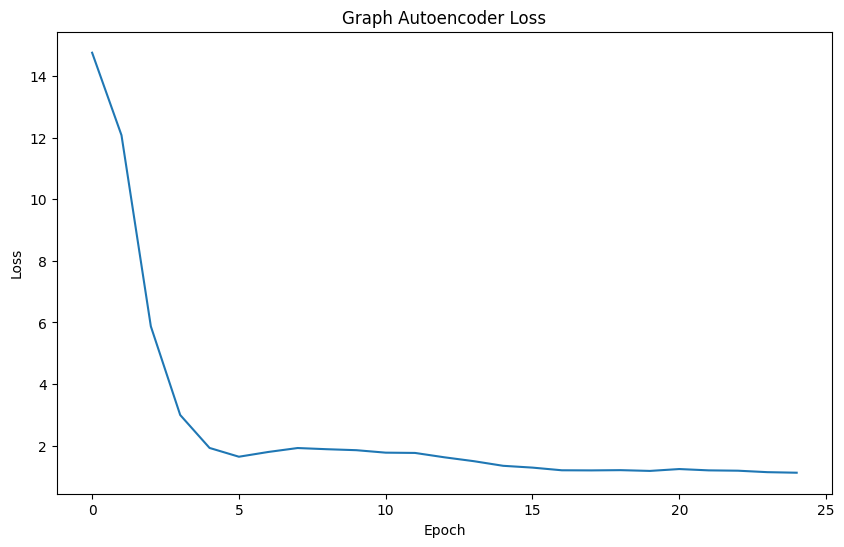

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(gae_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Graph Autoencoder Loss')
plt.show()

Once trained, generate the final embeddings (detached from the gradient graph)

In [ ]:
gae_model.eval()
with torch.no_grad():
    Z_train = model.encode(X_train_tensor, edge_index).cpu().numpy()

# Multilayer Perceptron (MLP)

MLP for estimating gene expression

Split data

In [ ]:
# Get embeddings from GAE
Z_tensor = torch.tensor(Z_train, dtype=torch.float32).to(device)

# Get the row indices for the Target Genes
target_indices = [gene_to_index[g] for g in Y_train_df.index
                  if g in gene_to_index]

# MLP Inputs: The 32-D embeddings of the TARGET Genes
mlp_inputs = Z_tensor[target_indices]

# MLP Targets: The actual expression values of the TARGET Genes
mlp_targets = Y_train_tensor.to(device)

print(f"MLP Input Shape: {mlp_inputs.shape}")
print(f"MLP Target Shape: {mlp_targets.shape}")

# Split our Target Genes (rows) into 80% Train and 20% Test
X_train_genes, X_test_genes, Y_train_genes, Y_test_genes = train_test_split(
    mlp_inputs.cpu().numpy(),
    mlp_targets.cpu().numpy(),
    test_size=0.20,
    random_state=42
)

# Convert back to tensors
X_train_genes = torch.tensor(X_train_genes, dtype=torch.float32).to(device)
X_test_genes = torch.tensor(X_test_genes, dtype=torch.float32).to(device)
Y_train_genes = torch.tensor(Y_train_genes, dtype=torch.float32).to(device)
Y_test_genes = torch.tensor(Y_test_genes, dtype=torch.float32).to(device)

MLP Input Shape: torch.Size([17893, 32])
MLP Target Shape: torch.Size([17893, 558])


## Training

In [ ]:
# Initialize MLP
mlp_model = ExpressionMLP(
    input_dim=32,
    hidden_dim=512,
    output_dim=558
).to(device)

# Train on the 80% split
trained_mlp, mlp_losses = train_mlp(
    mlp_model,
    X_train_genes,
    Y_train_genes,
    epochs=80,
    lr=0.001
)

MLP Epoch: 001 | MSE Loss: 0.9975
MLP Epoch: 020 | MSE Loss: 0.7972
MLP Epoch: 040 | MSE Loss: 0.3773
MLP Epoch: 060 | MSE Loss: 0.3681
MLP Epoch: 080 | MSE Loss: 0.3671


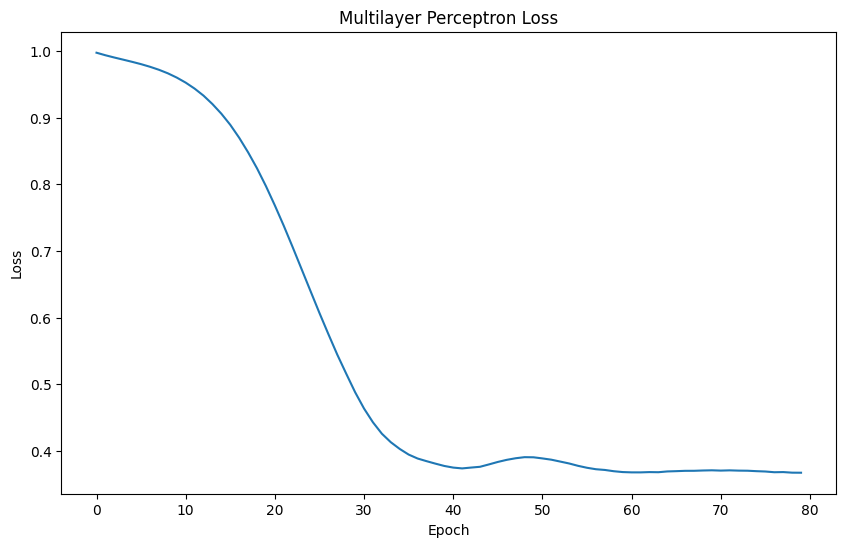

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(mlp_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Multilayer Perceptron Loss')
plt.show()

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.6 MB/s eta 0:00:00


In [ ]:
class ExpressionMLP(nn.Module):
    # Added dropout parameter here with a default of 0.2
    def __init__(self, input_dim=32, hidden_dim=64, output_dim=1, dropout=0.2):
        super(ExpressionMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout), # Using the dynamic dropout rate
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
import optuna
import torch
import torch.optim as optim
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch_geometric.nn import GAE

# Ensure device is set
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):
    # ====================================================
    # 1. Hyperparameters to Tune
    # ====================================================
    # GAE Parameters
    # out_channels defines the size of the latent embedding space
    out_channels = trial.suggest_categorical('out_channels', [16, 32, 64, 128])
    gae_lr = trial.suggest_float('gae_lr', 1e-4, 1e-2, log=True)
    gae_epochs = trial.suggest_categorical('gae_epochs', [25, 50])

    # MLP Parameters
    mlp_hidden = trial.suggest_categorical('mlp_hidden_dim', [128, 256, 512])
    mlp_lr = trial.suggest_float('mlp_lr', 1e-4, 1e-2, log=True)
    mlp_dropout = trial.suggest_float('mlp_dropout', 0.1, 0.5)

    # ====================================================
    # 2. Train the Graph Autoencoder (GAE)
    # ====================================================
    in_channels = X_train_tensor.shape[1]

    # Initialize GAE
    encoder = ShallowEncoder(in_channels, out_channels)
    gae_model = GAE(encoder).to(device)
    gae_optimizer = torch.optim.Adam(gae_model.parameters(), lr=gae_lr)

    # Train GAE (Note: using your custom train_gae function)
    gae_model, _ = train_gae(gae_model, gae_optimizer, X_train_tensor, edge_index, epochs=gae_epochs)

    # ====================================================
    # 3. Extract and Split Embeddings for the MLP
    # ====================================================
    gae_model.eval()
    with torch.no_grad():
        # Encode graph into latent representation Z
        Z_train = gae_model.encode(X_train_tensor, edge_index)

    # Get the embeddings specifically for the Target Genes
    target_indices = [gene_to_index[g] for g in Y_train_df.index if g in gene_to_index]
    mlp_inputs = Z_train[target_indices]
    mlp_targets = Y_train_tensor.to(device)

    # Split the embeddings 80/20 for the MLP
    # We do this here because mlp_inputs shape changes if out_channels changes!
    X_train_genes, X_test_genes, Y_train_genes, Y_test_genes = train_test_split(
        mlp_inputs.cpu().numpy(),
        mlp_targets.cpu().numpy(),
        test_size=0.20,
        random_state=42
    )

    # Convert back to tensors on device
    X_train_genes = torch.tensor(X_train_genes, dtype=torch.float32).to(device)
    X_test_genes = torch.tensor(X_test_genes, dtype=torch.float32).to(device)
    Y_train_genes = torch.tensor(Y_train_genes, dtype=torch.float32).to(device)
    Y_test_genes = torch.tensor(Y_test_genes, dtype=torch.float32).to(device)

    # ====================================================
    # 4. Train the MLP
    # ====================================================
    output_dim = Y_train_genes.shape[1]

    # IMPORTANT: Ensure your ExpressionMLP in utils.py accepts the 'dropout' parameter
    mlp_model = ExpressionMLP(
        input_dim=out_channels,
        hidden_dim=mlp_hidden,
        output_dim=output_dim,
        dropout=mlp_dropout
    ).to(device)

    # Train MLP
    mlp_model, _ = train_mlp(mlp_model, X_train_genes, Y_train_genes, epochs=80, lr=mlp_lr)

    # ====================================================
    # 5. Evaluate and Return Metric
    # ====================================================
    mlp_model.eval()
    criterion = nn.MSELoss()

    with torch.no_grad():
        # Predict on the unseen 20% validation split
        test_predictions = mlp_model(X_test_genes)
        test_mse = criterion(test_predictions, Y_test_genes).item()

    # Optuna will minimize this test MSE
    return test_mse

# ====================================================
# Run the Optuna Study
# ====================================================
if __name__ == "__main__":
    print("Starting Optuna Hyperparameter Search...")

    # We want to minimize the test Mean Squared Error
    study = optuna.create_study(direction='minimize')

    # Start with 20 trials (you can increase this later if you have more time/compute)
    study.optimize(objective, n_trials=50)

    print("\n" + "="*50)
    print("Optimization Finished!")
    print(f"Best Trial Test MSE: {study.best_trial.value:.4f}")
    print("Best Hyperparameters:")
    for key, value in study.best_trial.params.items():
        print(f"  {key}: {value}")

[I 2026-04-16 03:43:08,794] A new study created in memory with name: no-name-3faac2ef-e6ae-4c80-aa01-06bcf686b7ef


Starting Optuna Hyperparameter Search...
Epoch: 001 | GAE Recon Loss: 17.0761
Epoch: 010 | GAE Recon Loss: 2.9370
Epoch: 020 | GAE Recon Loss: 1.7697
Epoch: 030 | GAE Recon Loss: 1.3113
Epoch: 040 | GAE Recon Loss: 1.1877


[I 2026-04-16 03:43:09,157] Trial 0 finished with value: 0.985861599445343 and parameters: {'out_channels': 128, 'gae_lr': 0.0013133610185340537, 'gae_epochs': 50, 'mlp_hidden_dim': 256, 'mlp_lr': 0.0002654477533384512, 'mlp_dropout': 0.3655208465948504}. Best is trial 0 with value: 0.985861599445343.


Epoch: 050 | GAE Recon Loss: 1.0585
MLP Epoch: 001 | MSE Loss: 0.9984
MLP Epoch: 020 | MSE Loss: 0.9956
MLP Epoch: 040 | MSE Loss: 0.9941
MLP Epoch: 060 | MSE Loss: 0.9930
MLP Epoch: 080 | MSE Loss: 0.9919
Epoch: 001 | GAE Recon Loss: 15.5748
Epoch: 010 | GAE Recon Loss: 3.6169


[I 2026-04-16 03:43:09,396] Trial 1 finished with value: 0.2581641376018524 and parameters: {'out_channels': 64, 'gae_lr': 0.00032075519106325765, 'gae_epochs': 25, 'mlp_hidden_dim': 512, 'mlp_lr': 0.005087367069123469, 'mlp_dropout': 0.41459365213413746}. Best is trial 1 with value: 0.2581641376018524.


...

Epoch: 040 | GAE Recon Loss: 1.2077
Epoch: 050 | GAE Recon Loss: 1.1012
MLP Epoch: 001 | MSE Loss: 0.9975
MLP Epoch: 020 | MSE Loss: 0.9899
MLP Epoch: 040 | MSE Loss: 0.9545
MLP Epoch: 060 | MSE Loss: 0.6240
MLP Epoch: 080 | MSE Loss: 0.3599
Epoch: 001 | GAE Recon Loss: 12.0478
Epoch: 010 | GAE Recon Loss: 1.8854
Epoch: 020 | GAE Recon Loss: 1.2840
Epoch: 030 | GAE Recon Loss: 1.1247
Epoch: 040 | GAE Recon Loss: 1.0405
Epoch: 050 | GAE Recon Loss: 0.9879


[I 2026-04-16 03:43:25,652] Trial 48 finished with value: 0.3911731243133545 and parameters: {'out_channels': 32, 'gae_lr': 0.0007107893031538235, 'gae_epochs': 50, 'mlp_hidden_dim': 512, 'mlp_lr': 0.0031301045722427127, 'mlp_dropout': 0.4376546983762585}. Best is trial 38 with value: 0.1601456105709076.


MLP Epoch: 001 | MSE Loss: 0.9979
MLP Epoch: 020 | MSE Loss: 0.4232
MLP Epoch: 040 | MSE Loss: 0.4084
MLP Epoch: 060 | MSE Loss: 0.4012
MLP Epoch: 080 | MSE Loss: 0.4029
Epoch: 001 | GAE Recon Loss: 16.4771
Epoch: 010 | GAE Recon Loss: 12.6822
Epoch: 020 | GAE Recon Loss: 3.1715


[I 2026-04-16 03:43:25,984] Trial 49 finished with value: 0.32685586810112 and parameters: {'out_channels': 128, 'gae_lr': 0.0036171280266771976, 'gae_epochs': 50, 'mlp_hidden_dim': 128, 'mlp_lr': 0.0024052731089756665, 'mlp_dropout': 0.2895158656445764}. Best is trial 38 with value: 0.1601456105709076.


Epoch: 030 | GAE Recon Loss: 1.6736
Epoch: 040 | GAE Recon Loss: 1.2547
Epoch: 050 | GAE Recon Loss: 1.0756
MLP Epoch: 001 | MSE Loss: 1.0025
MLP Epoch: 020 | MSE Loss: 0.9936
MLP Epoch: 040 | MSE Loss: 0.9874
MLP Epoch: 060 | MSE Loss: 0.6057
MLP Epoch: 080 | MSE Loss: 0.3366

Optimization Finished!
Best Trial Test MSE: 0.1601
Best Hyperparameters:
  out_channels: 128
  gae_lr: 0.008246966589515526
  gae_epochs: 50
  mlp_hidden_dim: 512
  mlp_lr: 0.002197353372593393
  mlp_dropout: 0.3936714742131219


Training Final GAE...
Epoch: 001 | GAE Recon Loss: 16.8348
Epoch: 010 | GAE Recon Loss: 17.4125
Epoch: 020 | GAE Recon Loss: 18.0692
Epoch: 030 | GAE Recon Loss: 17.7413
Epoch: 040 | GAE Recon Loss: 16.8017
Epoch: 050 | GAE Recon Loss: 17.4867

Training Final MLP...
MLP Epoch: 001 | MSE Loss: 1.1108
MLP Epoch: 020 | MSE Loss: 0.2136
MLP Epoch: 040 | MSE Loss: 0.1892
MLP Epoch: 060 | MSE Loss: 0.1822
MLP Epoch: 080 | MSE Loss: 0.1813

Final Model Results:


,Metric,Train (Seen Genes),Test (Unseen Genes)
0,MSE (Scaled),0.1791,0.1663
1,MAE (TPM),13.1063,12.4299
2,MSE (TPM),64477.9382,61166.0924
3,Spearman Correlation,0.9025,0.9043


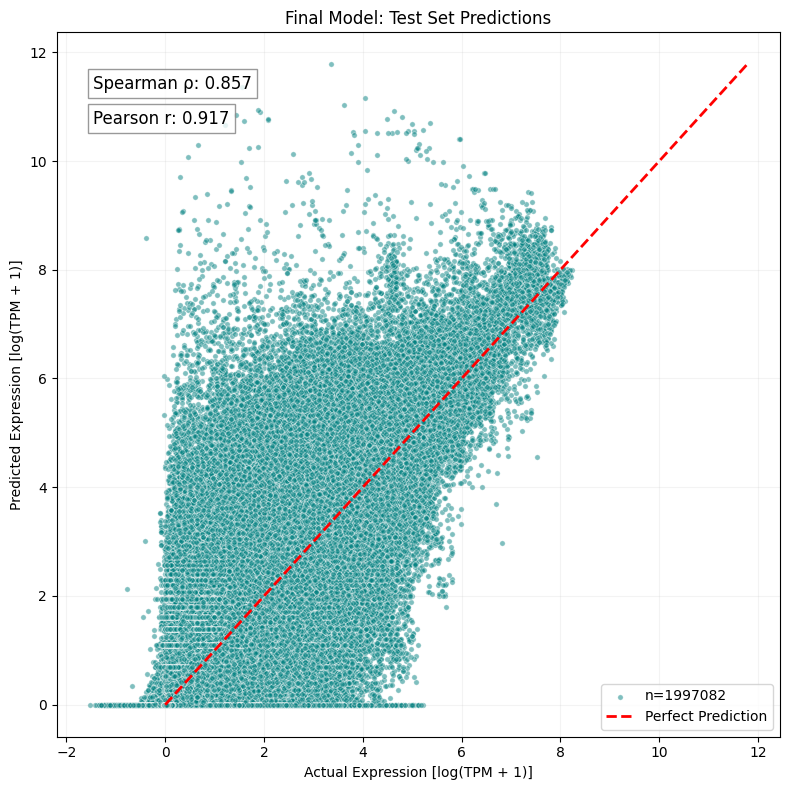

In [ ]:
# ==========================================
# 1. FINAL GAE TRAINING
# ==========================================
# best_out_channels = 128
# best_gae_lr = 0.00874
# best_gae_epochs = 50

best_out_channels = 128
best_gae_lr = 0.006600571153245659
best_gae_epochs = 50

print("Training Final GAE...")
in_channels = X_train_tensor.shape[1]
final_encoder = ShallowEncoder(in_channels, best_out_channels)
final_gae = GAE(final_encoder).to(device)
final_gae_optimizer = torch.optim.Adam(final_gae.parameters(), lr=best_gae_lr)

# Train the GAE
final_gae, final_gae_losses = train_gae(
    final_gae, final_gae_optimizer, X_train_tensor, edge_index, epochs=best_gae_epochs
)

# ==========================================
# 2. EXTRACT EMBEDDINGS
# ==========================================
final_gae.eval()
with torch.no_grad():
    Z_final = final_gae.encode(X_train_tensor, edge_index)

# Get the embeddings specifically for the Target Genes
target_indices = [gene_to_index[g] for g in Y_train_df.index if g in gene_to_index]
mlp_inputs = Z_final[target_indices]
mlp_targets = Y_train_tensor.to(device)

# Split 80/20
X_train_genes, X_test_genes, Y_train_genes, Y_test_genes = train_test_split(
    mlp_inputs.cpu().numpy(),
    mlp_targets.cpu().numpy(),
    test_size=0.20,
    random_state=42
)

# Convert to tensors
X_train_genes = torch.tensor(X_train_genes, dtype=torch.float32).to(device)
X_test_genes = torch.tensor(X_test_genes, dtype=torch.float32).to(device)
Y_train_genes = torch.tensor(Y_train_genes, dtype=torch.float32).to(device)
Y_test_genes = torch.tensor(Y_test_genes, dtype=torch.float32).to(device)

# ==========================================
# 3. FINAL MLP TRAINING
# ==========================================
# best_mlp_hidden = 256
# best_mlp_lr = 0.00133
# best_mlp_dropout = 0.3847

best_mlp_hidden = 512
best_mlp_lr = 0.001888866859433478
best_mlp_dropout = 0.18391499794566937

output_dim = Y_train_genes.shape[1]

print("\nTraining Final MLP...")
final_mlp = ExpressionMLP(
    input_dim=best_out_channels,
    hidden_dim=best_mlp_hidden,
    output_dim=output_dim,
    dropout=best_mlp_dropout
).to(device)

# Train the MLP
final_mlp, final_mlp_losses = train_mlp(
    final_mlp, X_train_genes, Y_train_genes, epochs=80, lr=best_mlp_lr
)

# ==========================================
# 4. EVALUATE FINAL PERFORMANCE
# ==========================================
print("\nFinal Model Results:")
results_df, (train_tar, train_pred, test_tar, test_pred) = get_mlp_results(
    final_mlp, Y_train_genes, Y_test_genes,
    X_train_genes, X_test_genes, scaler, train_exps,
    clean_exp_data.columns.tolist()
)

# Display the performance metrics
display(results_df.round(4))

# Plot the predictions for the Test set (unseen genes)
plot_expression_predictions(test_tar, test_pred, title="Final Model: Test Set Predictions")

# Evaluation

In [ ]:
results_df, (train_tar, train_pred, test_tar, test_pred) = get_mlp_results(
    trained_mlp, Y_train_genes, Y_test_genes,
    X_train_genes, X_test_genes, scaler, train_exps,
    clean_exp_data.columns.tolist()
)
results_df.round(4)

,Metric,Train (Seen Genes),Test (Unseen Genes)
0,MSE (Scaled),0.3358,0.3284
1,MAE (TPM),17.3238,17.0973
2,MSE (TPM),74746.6783,67641.7474
3,Spearman Correlation,0.8223,0.8218


In [ ]:
print(results_df.round(4))

                 Metric  Train (Seen Genes)  Test (Unseen Genes)
0          MSE (Scaled)              0.3358               0.3284
1             MAE (TPM)             17.3238              17.0973
2             MSE (TPM)          74746.6783           67641.7474
3  Spearman Correlation              0.8223               0.8218


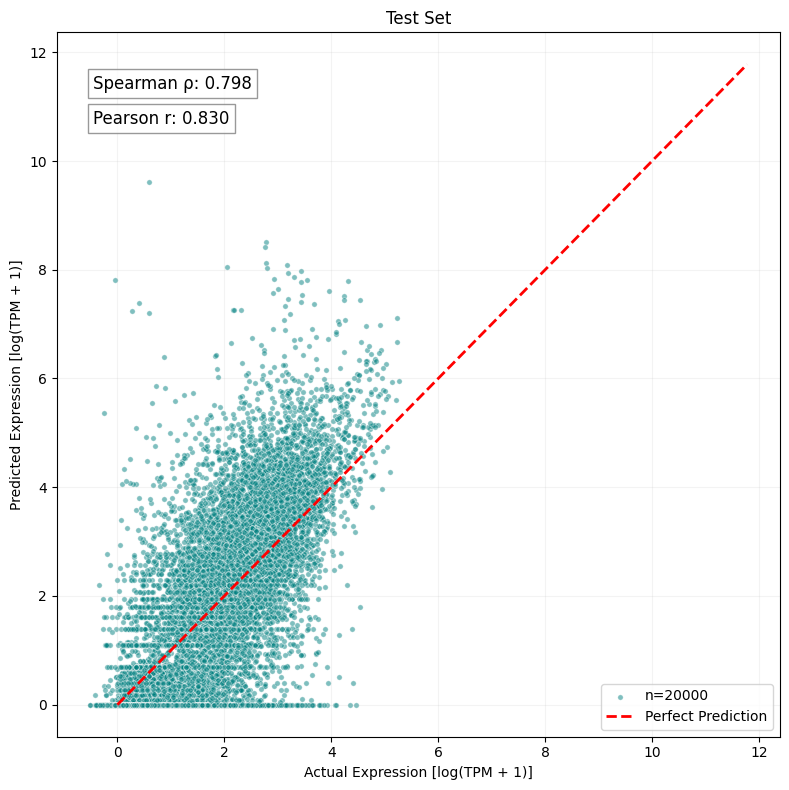

In [ ]:
plot_expression_predictions(test_tar, test_pred, title='Test Set',
                            sample_size=20000)

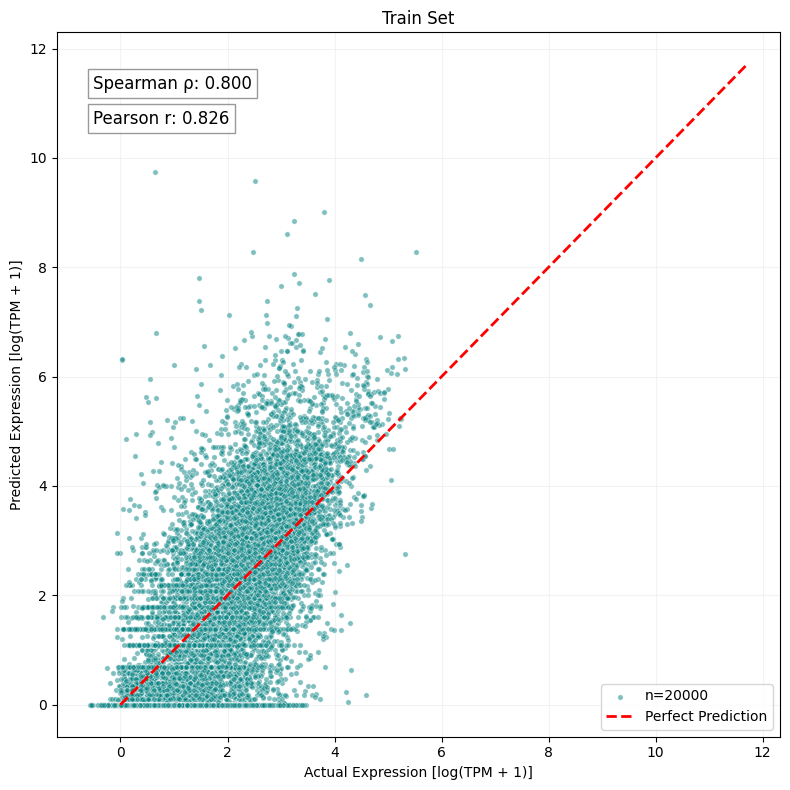

In [ ]:
plot_expression_predictions(train_tar, train_pred, title='Train Set',
                            sample_size=20000)